# **Curso IA desde Cero**

* Dr. Irvin Hussein López Nava
* M.C. Joan M. Raygoza Romero

# Instalar Mediapipe

In [ ]:
!pip install mediapipe

# Visualizar keypoints

## Importar librerias

In [ ]:
import numpy as np
import mediapipe as mp
import os
import cv2
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import clear_output
from google.colab import output
from base64 import b64decode

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [ ]:
!wget -q -O face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task

## Función para poder leer una imagen de la webcam en colab

In [ ]:
def get_webcam(quality=0.8):
    js = """
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capturar frame';
      capture.style.fontSize = '20px';
      capture.style.marginBottom = '10px';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      video.width = 640;
      video.height = 480;
      div.appendChild(video);

      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      // Esperar click
      await new Promise(resolve => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(t => t.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }

    takePhoto(%f)
    """ % quality

    data = output.eval_js(js)
    binary = b64decode(data.split(',')[1])
    img_array = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

## Preparar face mesh para extraer keypoints

In [ ]:
base_options = python.BaseOptions(model_asset_path="face_landmarker.task")

options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

face_landmarker = vision.FaceLandmarker.create_from_options(options)

### Seleccionar keypoints que nos quedaremos

In [ ]:
IMPORTANT_KEYPOINTS = {
    # ---- REFERENCIAS / NORMALIZACIÓN ----
    "nose_tip": 1,
    "nose_bridge": 6,
    "forehead_center": 10,
    "chin": 152,

    # ---- BOCA (EXTERNA E INTERNA) ----
    "mouth_left": 61,
    "mouth_right": 291,
    "mouth_upper_outer": 13,
    "mouth_lower_outer": 14,
    "mouth_upper_inner": 0,
    "mouth_lower_inner": 17,
    "mouth_left_inner": 40,
    "mouth_right_inner": 270,
    "mouth_corner_left_top": 84,
    "mouth_corner_left_bottom": 181,
    "mouth_corner_right_top": 314,
    "mouth_corner_right_bottom": 405,

    # ---- OJO IZQUIERDO ----
    "left_eye_outer": 33,
    "left_eye_inner": 133,
    "left_eye_upper": 159,
    "left_eye_lower": 145,
    "left_eye_upper_inner": 158,
    "left_eye_lower_inner": 153,
    "left_eye_upper_outer": 160,
    "left_eye_lower_outer": 144,

    # ---- OJO DERECHO ----
    "right_eye_outer": 263,
    "right_eye_inner": 362,
    "right_eye_upper": 386,
    "right_eye_lower": 374,
    "right_eye_upper_inner": 385,
    "right_eye_lower_inner": 380,
    "right_eye_upper_outer": 387,
    "right_eye_lower_outer": 373,

    # ---- CEJA IZQUIERDA ----
    "left_eyebrow_outer": 70,
    "left_eyebrow_middle": 105,
    "left_eyebrow_inner": 107,
    "left_eyebrow_lower_outer": 46,
    "left_eyebrow_lower_middle": 52,
    "left_eyebrow_lower_inner": 55,

    # ---- CEJA DERECHA ----
    "right_eyebrow_outer": 300,
    "right_eyebrow_middle": 334,
    "right_eyebrow_inner": 336,
    "right_eyebrow_lower_outer": 285,
    "right_eyebrow_lower_middle": 282,
    "right_eyebrow_lower_inner": 276
}

IMPORTANT_KEYPOINTS_IDX_LIST = list(IMPORTANT_KEYPOINTS.values())
KEY_NAMES = list(IMPORTANT_KEYPOINTS.keys())

## Función para dibujar los keypoints en la imagen

In [ ]:
def draw_keypoints(frame, face_landmarks, IMPORTANT_KEYPOINTS):
    annotated = frame.copy()
    h, w, _ = frame.shape

    for name, idx in IMPORTANT_KEYPOINTS.items():
        lm = face_landmarks[idx]
        cx, cy = int(lm.x * w), int(lm.y * h)

        cv2.circle(annotated, (cx, cy), 2, (0, 0, 255), 1)
        cv2.putText(
            annotated,
            str(idx),
            (cx + 3, cy + 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.2,
            (0, 255, 0),
            1
        )

    annotated_result = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    return annotated_result

## Ejemplo de leer una imagen de la webcam y dibujar los keypoints

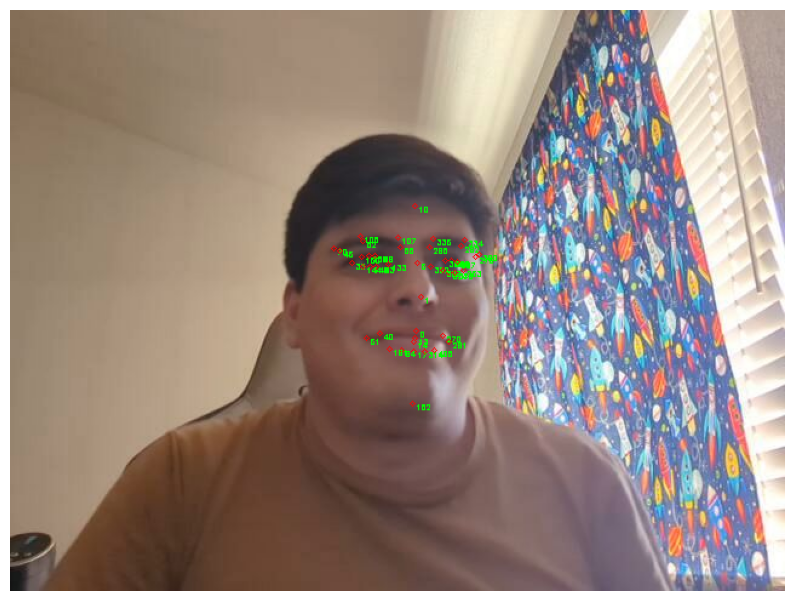

In [ ]:
frame = get_webcam()

img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=img_rgb
)

results = face_landmarker.detect(mp_image)

if len(results.face_landmarks) == 0:
    print("No se detectó ningún rostro.")
else:
    face_landmarks = results.face_landmarks[0]

    important_landmarks = []

    for idx in IMPORTANT_KEYPOINTS_IDX_LIST:
        lm = face_landmarks[idx]
        important_landmarks.append([lm.x, lm.y])

    annotated_img = draw_keypoints(frame, face_landmarks, IMPORTANT_KEYPOINTS)

    clear_output(wait=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_img)
    plt.axis("off")
    plt.show()

# Haciendo un modelo

### Funciones

In [ ]:
def extract_keypoints(
    img_rgb,
    face_landmarker,
    IMPORTANT_KEYPOINTS_IDX_LIST,
    normalization=False,
    head_orientation=False
):
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=img_rgb
    )

    results = face_landmarker.detect(mp_image)

    if len(results.face_landmarks) == 0:
        return None

    face_landmarks = results.face_landmarks[0]

    important_landmarks = []

    for idx in IMPORTANT_KEYPOINTS_IDX_LIST:
        lm = face_landmarks[idx]
        important_landmarks.append([lm.x, lm.y])

    keypoints_array = np.array(important_landmarks)

    le_lm = face_landmarks[IMPORTANT_KEYPOINTS["left_eye_inner"]]
    re_lm = face_landmarks[IMPORTANT_KEYPOINTS["right_eye_inner"]]

    left_eye = np.array([le_lm.x, le_lm.y])
    right_eye = np.array([re_lm.x, re_lm.y])

    anchor = (left_eye + right_eye) / 2
    keypoints_array = keypoints_array - anchor

    if normalization:
        eye_vec = right_eye - left_eye
        eye_dist = np.linalg.norm(eye_vec)

        if eye_dist > 0:
            keypoints_array = keypoints_array / eye_dist

    if head_orientation:
        eye_vec = right_eye - left_eye
        angle = np.arctan2(eye_vec[1], eye_vec[0])

        R = np.array([
            [np.cos(-angle), -np.sin(-angle)],
            [np.sin(-angle),  np.cos(-angle)]
        ])

        keypoints_array = keypoints_array @ R.T

    return keypoints_array.flatten()

In [ ]:
def extract_keypoints_dataset(
    base_path,
    IMPORTANT_KEYPOINTS_IDX_LIST,
    normalization=False,
    head_orientation=False):
    keypoints_data = []
    paths = []
    users = []
    labels = []

    base_options = python.BaseOptions(
        model_asset_path="face_landmarker.task"
    )

    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.IMAGE,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5
    )

    face_landmarker = vision.FaceLandmarker.create_from_options(options)

    folders = os.listdir(base_path)

    for folder in folders:
        print(folder)

        folder_path = os.path.join(base_path, folder)

        for user in os.listdir(folder_path):
            user_path = os.path.join(folder_path, user)

            filenames = os.listdir(user_path)

            for img_filename in filenames:
                img_path = os.path.join(user_path, img_filename)

                img = cv2.imread(img_path)

                if img is None:
                    continue

                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                keypoints_array = extract_keypoints(
                    img_rgb,
                    face_landmarker,
                    IMPORTANT_KEYPOINTS_IDX_LIST,
                    normalization,
                    head_orientation
                )

                keypoints_data.append(keypoints_array)
                labels.append(folder)
                paths.append(img_path)
                users.append(user)

    df = pd.concat(
        (
            pd.DataFrame(keypoints_data),
            pd.DataFrame(paths, columns=["path"]),
            pd.DataFrame(users, columns=["user"]),
            pd.DataFrame(labels, columns=["class"])
        ),
        axis=1
    )

    return df


## Extraer los keypoints de nuestro conjunto de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = extract_keypoints_dataset('/content/drive/MyDrive/IA desde cero/emotion', IMPORTANT_KEYPOINTS_IDX_LIST, normalization=True, head_orientation=True)
df.to_csv('keypoints.csv', index=False)

angry
happy
neutral
sad


## Leer conjunto de datos

In [ ]:
df = pd.read_csv('keypoints.csv')
print(df.shape)
df.head()

(255, 91)


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,path,user,class
0,-0.030226,1.073829,-0.007830,0.103606,0.015178,-1.421408,-0.065144,3.017266,-0.792895,1.806656,...,-0.524643,0.369661,-0.311534,1.145616,-0.451228,1.538408,-0.302044,/content/drive/MyDrive/IA desde cero/emotion/a...,hussein,angry
1,-0.043945,1.126992,-0.037814,0.124146,-0.040867,-1.426080,0.052834,3.278412,-0.668942,1.988207,...,-0.465352,0.322952,-0.247876,1.090580,-0.380181,1.518135,-0.252318,/content/drive/MyDrive/IA desde cero/emotion/a...,MiguelCC,angry
2,-0.040831,1.229581,-0.035411,0.121377,-0.048786,-1.574914,0.021968,3.383666,-0.729786,2.074915,...,-0.535634,0.340296,-0.298236,1.143135,-0.448203,1.578932,-0.309963,/content/drive/MyDrive/IA desde cero/emotion/a...,MiguelCC,angry
3,-0.014852,1.225626,-0.020344,0.194126,-0.054182,-1.422700,0.075096,3.176803,-0.593374,1.901469,...,-0.398089,0.311440,-0.190762,1.072153,-0.359720,1.484261,-0.275707,/content/drive/MyDrive/IA desde cero/emotion/a...,MiguelCC,angry
4,0.062353,1.367413,0.033809,0.193399,-0.021212,-1.577064,0.022155,3.375166,-0.679368,2.106797,...,-0.484137,0.381611,-0.251582,1.151810,-0.430541,1.540870,-0.339433,/content/drive/MyDrive/IA desde cero/emotion/a...,MiguelCC,angry


In [ ]:
df['user'].unique()

array(['hussein', 'MiguelCC', 'VerónicaMA', 'César Trujillo',
       'Ahinojosa', 'MP', 'Alexander', 'renee'], dtype=object)

## Histograma de usuarios

<Axes: >

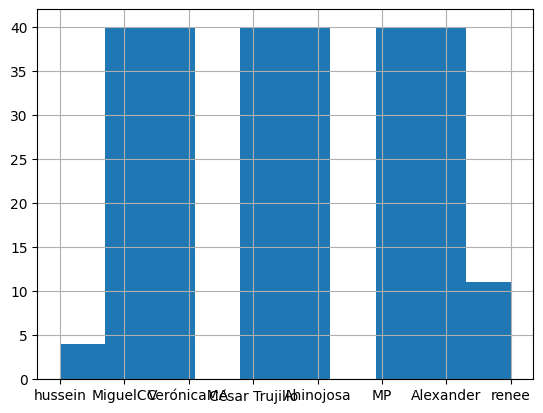

In [ ]:
df['user'].hist()

## Distribución de clases

<Axes: >

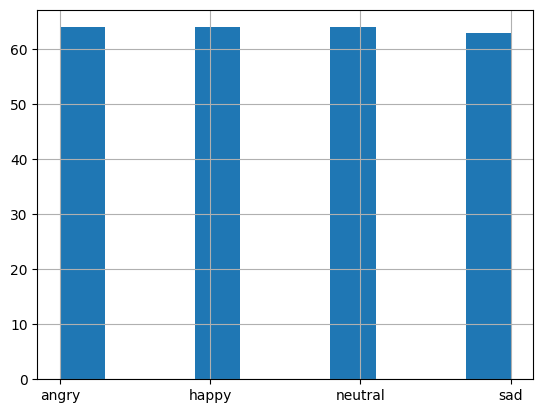

In [ ]:
df['class'].hist()

## Funciones para extraer características

In [ ]:
def distance(a, b):
    """Distancia euclidiana 2D simple."""
    return float(np.linalg.norm(a - b))


def build_feature_vector(keypoints):
    pts = keypoints.reshape(-1, 2)  # (n_points, 2)

    # Mapeo nombre -> punto (x,y)
    P = {name: pts[i] for i, name in enumerate(KEY_NAMES)}

    feats = []

    # ---------- BOCA ----------
    mouth_width = distance(P["mouth_left"], P["mouth_right"])
    mouth_open_outer = abs(P["mouth_upper_outer"][1] - P["mouth_lower_outer"][1])
    mouth_open_inner = abs(P["mouth_upper_inner"][1] - P["mouth_lower_inner"][1])

    # “curvatura” de la sonrisa (boca hacia arriba/abajo)
    mean_corner_y = 0.5 * (P["mouth_left"][1] + P["mouth_right"][1])
    smile_curvature = mean_corner_y - P["mouth_lower_outer"][1]

    feats += [
        mouth_width,
        mouth_open_outer,
        mouth_open_inner,
        smile_curvature,
    ]

    # ---------- OJOS ----------
    # ojo izquierdo
    left_eye_open = distance(P["left_eye_upper"], P["left_eye_lower"])
    left_eye_open_inner = distance(P["left_eye_upper_inner"], P["left_eye_lower_inner"])
    left_eye_open_outer = distance(P["left_eye_upper_outer"], P["left_eye_lower_outer"])

    # ojo derecho
    right_eye_open = distance(P["right_eye_upper"], P["right_eye_lower"])
    right_eye_open_inner = distance(P["right_eye_upper_inner"], P["right_eye_lower_inner"])
    right_eye_open_outer = distance(P["right_eye_upper_outer"], P["right_eye_lower_outer"])

    feats += [
        left_eye_open,
        left_eye_open_inner,
        left_eye_open_outer,
        right_eye_open,
        right_eye_open_inner,
        right_eye_open_outer,
    ]

    # ---------- CEJAS (altura respecto al ojo y pendiente) ----------
    left_eye_center = 0.5 * (P["left_eye_inner"] + P["left_eye_outer"])
    right_eye_center = 0.5 * (P["right_eye_inner"] + P["right_eye_outer"])

    left_brow_height = left_eye_center[1] - P["left_eyebrow_middle"][1]
    right_brow_height = right_eye_center[1] - P["right_eyebrow_middle"][1]

    # pendiente (inclinación) de ceja: outer vs inner
    left_brow_slope = P["left_eyebrow_outer"][1] - P["left_eyebrow_inner"][1]
    right_brow_slope = P["right_eyebrow_outer"][1] - P["right_eyebrow_inner"][1]

    feats += [
        left_brow_height,
        right_brow_height,
        left_brow_slope,
        right_brow_slope,
    ]

    # ---------- PROPORCIONES CARA ----------
    # altura de cara: frente -> mentón
    face_height = distance(P["forehead_center"], P["chin"])
    # longitud nariz: nose_bridge -> nose_tip
    nose_length = distance(P["nose_bridge"], P["nose_tip"])

    # algunos ratios que son invariantes de escala
    mouth_width_ratio = mouth_width / face_height
    nose_face_ratio = nose_length / face_height

    feats += [
        face_height,
        nose_length,
        mouth_width_ratio,
        nose_face_ratio,
    ]

    return np.array(feats)

## Librearias para entrenar y evaluar modelos

In [ ]:
from sklearn.model_selection import KFold,StratifiedKFold,GroupKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

import pickle
import seaborn as sns

## Preparar datos de entrada y salida

In [ ]:
x = df.drop(['path', 'user','class'], axis=1).to_numpy()
x_features = np.vstack([build_feature_vector(row) for row in x])

le = LabelEncoder()
y = le.fit_transform(df['class'])

## Entrenamiento con validación cruzada

Test user: ['VerónicaMA']
Fold 0: 0.375
Test user: ['MiguelCC']
Fold 1: 0.8486842105263157
Test user: ['MP']
Fold 2: 0.5599137931034484
Test user: ['César Trujillo']
Fold 3: 0.3288961038961039
Test user: ['Alexander']
Fold 4: 0.26816239316239315
Test user: ['Ahinojosa']
Fold 5: 0.369281045751634
Test user: ['renee']
Fold 6: 0.4642857142857143
Test user: ['hussein']
Fold 7: 0.125
Mean F1 score macro: 0.5248112756597222
              precision    recall  f1-score   support

           0       0.50      0.38      0.43        64
           1       0.78      0.81      0.79        64
           2       0.39      0.56      0.46        64
           3       0.49      0.37      0.42        63

    accuracy                           0.53       255
   macro avg       0.54      0.53      0.52       255
weighted avg       0.54      0.53      0.53       255



Text(50.722222222222214, 0.5, 'True')

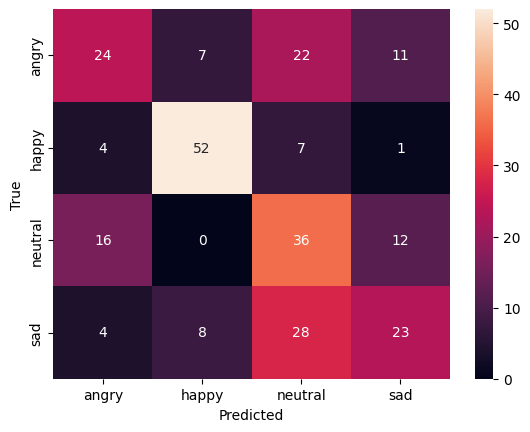

In [ ]:
kf = GroupKFold(n_splits=len(df['user'].unique()))
scores = []
conf_matrix = []
preds = []
true = []

for i, (train_index, test_index) in enumerate(kf.split(x_features,y,df['user'])):
    x_train = x_features[train_index]
    x_test = x_features[test_index]
    y_train = y[train_index]
    y_test = y[test_index]
    print(f"Test user: {df['user'].iloc[test_index].unique()}")
    model = LogisticRegression(random_state=0, max_iter=1000).fit(x_train, y_train)
    y_pred = model.predict(x_test)

    preds += list(y_pred)
    true += list(y_test)

    scores.append(f1_score(y_test, y_pred, average='macro'))
    matrix = confusion_matrix(y_test, y_pred)
    conf_matrix.append(matrix)
    #print(classification_report(y_test, y_pred))
    print(f"Fold {i}: {scores[-1]}")
print(f"Mean F1 score macro: {f1_score(true, preds, average='macro')}")
print(classification_report(true, preds))
sns.heatmap(np.sum(conf_matrix, axis=0), annot=True, fmt='g', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')

## Entrenar el modelo con todo el conjunto de datos y guardarlo junto con el label encoder

In [ ]:
model = LogisticRegression(random_state=0, max_iter=1000).fit(x_features, y)

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(le, open('le.pkl', 'wb'))

# Probar el modelo

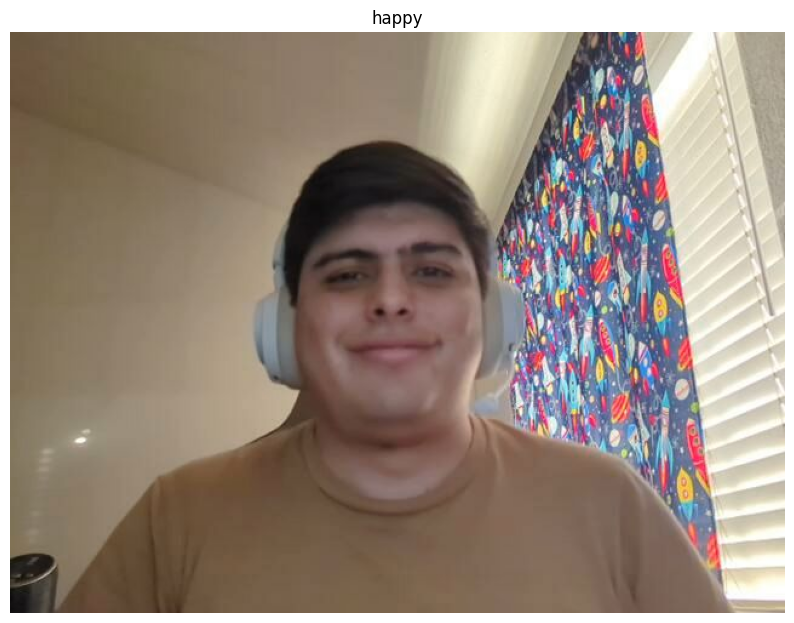

In [ ]:
frame = get_webcam()
keypoints_array = extract_keypoints(frame, face_landmarker, IMPORTANT_KEYPOINTS_IDX_LIST, normalization=True, head_orientation=True)
prediction = le.inverse_transform(model.predict(build_feature_vector(keypoints_array).reshape(1,-1)))

clear_output(wait=True)
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(prediction[0])
plt.axis('off')
plt.show()